# ANALISIS EXPLORATORIO DE DATOS (EDA)

## 1-CONFIGURACION Y CARGA DE DATOS

In [10]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker 
import os # Necesario para la ruta absoluta

ruta_base = r'G:\tecnicatura en cd e ia\2025\SEGUNDO AÑO\2do año 1er cuatrimestre\aprendizaje automatico\PROYECTOS AA\actividades de ML\PARCIAL_AA_2025\data\03-dataset listo para EDA'
nombre_archivo = 'importaciones_limpio_para_eda.parquet'
ruta_completa = os.path.join(ruta_base, nombre_archivo)

try:
    # Eliminamos 'decimal="."' ya que no es un parámetro válido para read_parquet
    df_eda = pd.read_parquet(ruta_completa) 
    
    print("✅ Datos cargados correctamente.")
    print(f"Instancias: {len(df_eda)}, Características: {len(df_eda.columns)}")
except FileNotFoundError:
    print(f"❌ Error: No se encontró el archivo en la ruta: {ruta_completa}")
    df_eda = pd.DataFrame() # Crear DF vacío para evitar errores posteriores

# --- Conversión de tipos de datos categóricos y temporales ---
if not df_eda.empty:
    # Usar el DF renombrado como df_eda (buena práctica para EDA)
    df_eda['NCM_8_digitos'] = df_eda['NCM_8_digitos'].astype(str)
    df_eda['Pais_Origen_Cod'] = df_eda['Pais_Origen_Cod'].astype(str)
    
    # Crear la columna de fecha (si las columnas 'Año' y 'mes' ya son int o str)
    df_eda['Fecha'] = pd.to_datetime(
        df_eda['Año'].astype(str) + '-' + df_eda['mes'].astype(str) + '-01'
    )
    
    # Revisión de la primera fila y tipos de datos
    print("\nPrimeras 5 filas (df_eda):")
    print(df_eda.head())
    print("\nTipos de datos de las nuevas columnas:")
    print(df_eda[['NCM_8_digitos', 'Pais_Origen_Cod', 'Fecha']].dtypes)

✅ Datos cargados correctamente.
Instancias: 347874, Características: 17

Primeras 5 filas (df_eda):
    Año  mes NCM_8_digitos Pais_Origen_Cod  Peso_Neto_kg  FOB(USD)  \
0  2024    1      01012100             200         500.0   6000.00   
1  2024    1      01012100             212        2500.0  19500.00   
2  2024    1      01012100             417         300.0  33490.76   
3  2024    1      01012900             200         450.0   5000.00   
4  2024    1      01012900             423        1000.0   9800.00   

   Flete(USD)  Seguro(USD)  CIF(USD)  Precio_Unitario_USD_kg NCM_4_digitos  \
0     3500.00        47.50   9547.50               12.000000          0101   
1    26000.01       455.01  45955.02                7.800000          0101   
2     3256.80       367.48  37115.04              111.635867          0101   
3     2500.00        75.00   7575.00               11.111111          0101   
4     6513.60       168.27  16481.87                9.800000          0101   

   Costo_L

# 2-Análisis del target: CIF(USD)

## El objetivo es entender la variable que estamos tratando de predecir.

### A. Distribución del Valor CIF

Analizamos la distribución para ver si es sesgada (lo cual es muy común en datos económicos).

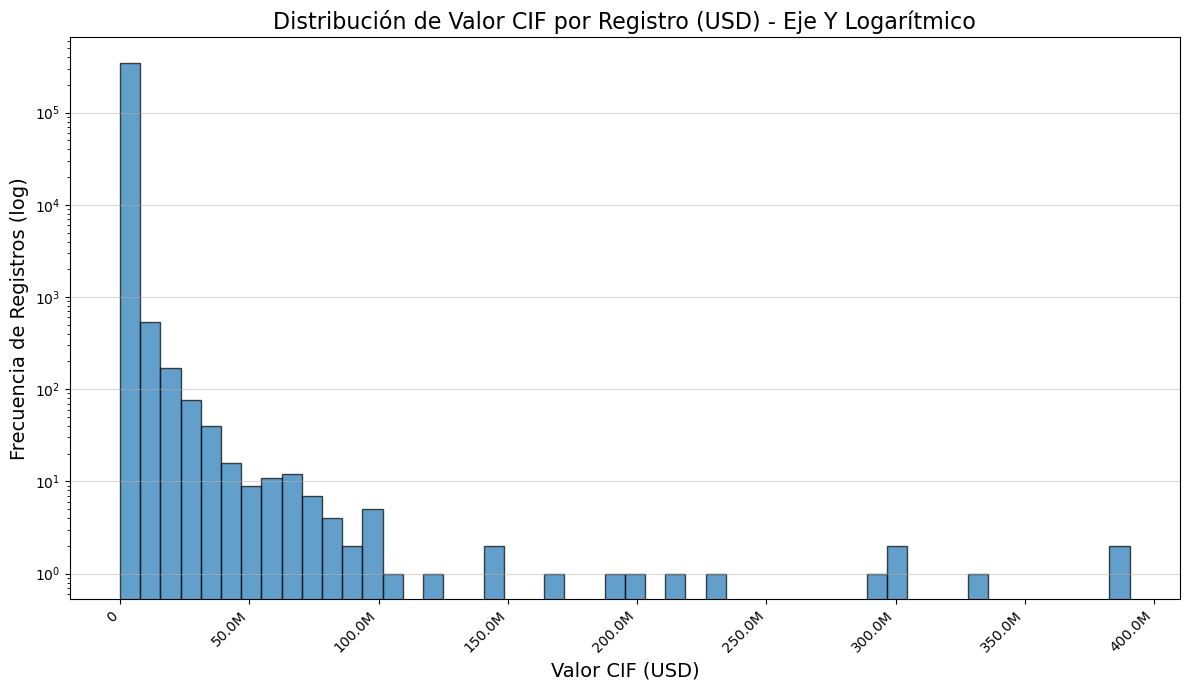

Estadísticas Descriptivas Clave de CIF(USD):
count       347874.000000
mean        174705.702551
std        2095671.441168
min              0.010000
25%           1132.325000
50%           9506.790000
75%          58336.690000
max      390448219.790000
Name: CIF(USD), dtype: object


In [6]:
# Función para dar formato a los números grandes (ej: 1000000 -> 1M)
def format_millions(x, pos):
    """Convierte un valor numérico a formato K o M."""
    if x >= 1e6:
        return f'{x*1e-6:.1f}M'
    elif x >= 1e3:
        return f'{x*1e-3:.0f}K'
    return f'{x:.0f}'

# --- Análisis del Target: CIF(USD) (Gráfico Ajustado) ---
plt.figure(figsize=(12, 7)) # Aumento el tamaño de la figura para más espacio
df_eda['CIF(USD)'].plot(kind='hist', bins=50, edgecolor='black', alpha=0.7)

# 1. Aplicar el formato abreviado (CRUCIAL para evitar superposición)
formatter = ticker.FuncFormatter(format_millions)
plt.gca().xaxis.set_major_formatter(formatter)

# 2. Rotar las etiquetas (Opcional, pero ayuda si el formato abreviado no es suficiente)
plt.xticks(rotation=45, ha='right')

# Ajustes de Título y Ejes
plt.yscale('log')
plt.title('Distribución de Valor CIF por Registro (USD) - Eje Y Logarítmico', fontsize=16)
plt.xlabel('Valor CIF (USD)', fontsize=14)
plt.ylabel('Frecuencia de Registros (log)', fontsize=14)
plt.grid(axis='y', alpha=0.5)
plt.tight_layout() # Ajusta automáticamente los parámetros para dar espacio a las etiquetas
plt.show()

# Estadísticas Descriptivas
print("Estadísticas Descriptivas Clave de CIF(USD):")
print(df_eda['CIF(USD)'].describe().apply(lambda x: format(x, 'f')))

## Insight: La distribución será altamente sesgada a la derecha (muchos registros con valores bajos y pocos con valores muy altos). Esto indica que los pocos productos de alto valor son muy importantes, y el modelo de regresión deberá ser robusto a los outliers.

### B. Serie de Tiempo Agregada (Tendencia y Estacionalidad)

Agregamos los datos para visualizar el comportamiento mensual total.

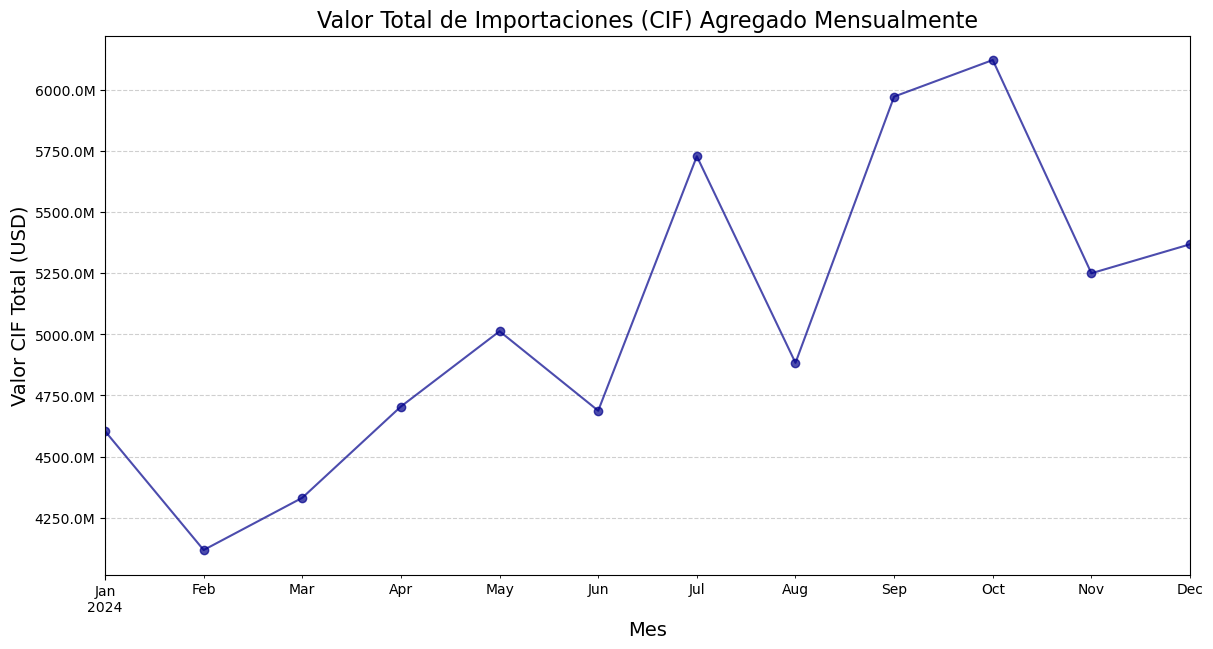


Top 5 Meses con Mayor Valor de Importación (CIF):
Fecha
2024-10-01    6.120464e+09
2024-09-01    5.970959e+09
2024-07-01    5.727054e+09
2024-12-01    5.367411e+09
2024-11-01    5.249072e+09
Name: CIF(USD), dtype: float64


In [9]:
# --- B. Serie de Tiempo Agregada (Tendencia y Estacionalidad) ---

# 1. Agrupar los datos mensualmente por el Valor CIF
# Creamos un DataFrame agregado donde el índice es la 'Fecha'
df_serie_tiempo = df_eda.groupby('Fecha')['CIF(USD)'].sum().reset_index()

# 2. Establecer la 'Fecha' como el índice para la gráfica
df_serie_tiempo.set_index('Fecha', inplace=True)


# 3. Graficar la Serie de Tiempo
plt.figure(figsize=(14, 7))
df_serie_tiempo['CIF(USD)'].plot(
    marker='o', 
    linestyle='-', 
    color='darkblue', 
    alpha=0.7
)

# Aplicar formato abreviado a los valores del eje Y (moneda)
def format_millions(x, pos):
    """Convierte un valor numérico a formato de Millones (M)."""
    if x >= 1e6:
        return f'{x*1e-6:.1f}M'
    return f'{x:.0f}'

formatter = ticker.FuncFormatter(format_millions)
plt.gca().yaxis.set_major_formatter(formatter)


plt.title('Valor Total de Importaciones (CIF) Agregado Mensualmente', fontsize=16)
plt.xlabel('Mes', fontsize=14)
plt.ylabel('Valor CIF Total (USD)', fontsize=14)
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()

# Opcional: Mostrar los 5 meses con el mayor valor CIF
print("\nTop 5 Meses con Mayor Valor de Importación (CIF):")
print(df_serie_tiempo['CIF(USD)'].sort_values(ascending=False).head())

## Insight:

### Tendencia general (Trend)

La tendencia se refiere a la dirección a largo plazo de la serie.

Considerando el valor inicial en enero (UsS 4.600 millones aprox) y el valor final en diciembre (U$S 5.400 millones aprox), la serie de tiempo muestra una tendencia ligeramente positiva o alcista a lo largo del año.

Evidencia: El nivel general de las importaciones (CIF) es significativamente más alto al final del año (octubre, noviembre, diciembre) que a principios (enero, febrero, marzo), a pesar de las fluctuaciones mensuales. El valor máximo de la serie es el doble del valor mínimo, lo que indica un fuerte crecimiento durante el periodo.

### Estacionalidad y ciclicidad

La estacionalidad se refiere a patrones que se repiten en periodos fijos y conocidos (como mensual, trimestral o anualmente). Aunque solo hay un año de datos, los patrones de alto y bajo nivel en meses específicos sugieren una posible estacionalidad, que se confirmaría con datos de varios años.

En el gráfico se revela un patrón de dos picos (bimodal) y un valle que es común en las series de tiempo económicas:

1. Valle de principios de año (Baja estacionalidad)

    Periodo: Febrero-Marzo.

    Comportamiento: Hay una caída notable en Febrero (U$S 4.250 millones aprox), seguido de un repunte ligero en Marzo. Esta baja al comienzo del año es a menudo estacional, coincidiendo con menos días hábiles o un período de menor actividad económica (como el impacto de las festividades de fin de año o las "vacaciones de verano" en ciertas economías).

2. Primer pico y asentamiento

    Periodo: Abril-Mayo.

    Comportamiento: Un fuerte crecimiento entre abril (UsS 4.750 millones aprox) y mayo (U$S 5.000 millones aprox), seguido de un retroceso en junio. Esto puede reflejar un primer pico de demanda o el momento en que se procesan y contabilizan las importaciones de insumos clave.

3. Segundo y mayor pico (Alta estacionalidad)

    Periodo: Julio y Septiembre-Octubre.

    Comportamiento: Este es el patrón más fuerte:

   * Julio registra un pico significativo (UsS 5.750 millones aprox).
   * Luego, tras un bache en agosto, las importaciones experimentan un crecimiento explosivo para alcanzar los máximos del año en Septiembre (poco menos de UsS 6.000 millones) y Octubre (mas de U$S 6.000 millones).

        Este comportamiento es altamente estacional y se relaciona típicamente con la preparación para el pico de ventas de fin de año (Navidad, "Black Friday", etc.) , donde las empresas acumulan inventario importado para satisfacer la demanda de los últimos meses del año.

4. Cierre de año

    Comportamiento: Una baja en noviembre y un repunte en diciembre. La baja de noviembre (USS 5.250) después del máximo de octubre es una corrección esperada, mientras que el repunte de diciembre (U$S 5.400) sugiere un movimiento final de stock o importaciones de última hora.

## Análisis de correlación (Heatmap)

### Para este análisis, nos enfocaremos en la correlación de Pearson (ρ) entre las variables numéricas y el target transformado (Log_Valor_CIF_USD).

✅ Variables de valor y peso transformadas logarítmicamente.


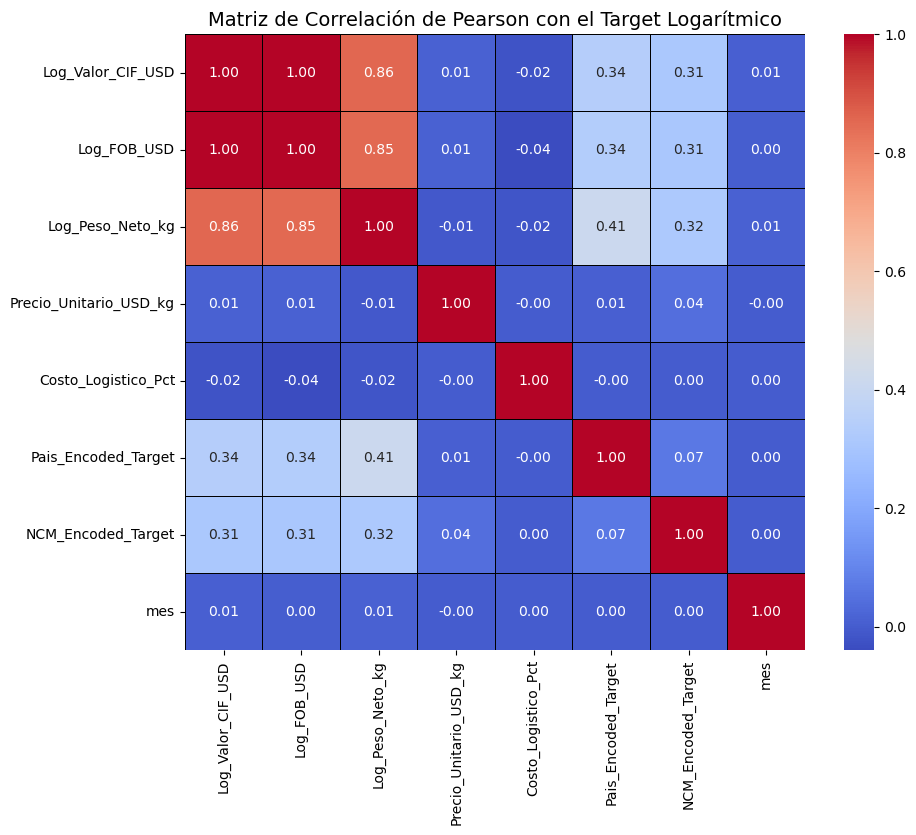

In [5]:
# Transformar las features de valor y peso (que son altamente sesgadas)
# El uso de np.log1p (log(1+x)) es crucial para manejar ceros de forma segura.
df_eda['Log_FOB_USD'] = np.log1p(df_eda['FOB(USD)'])
df_eda['Log_Peso_Neto_kg'] = np.log1p(df_eda['Peso_Neto_kg'])

# Opcional pero recomendado para consistencia:
df_eda['Log_Flete_USD'] = np.log1p(df_eda['Flete(USD)'])
df_eda['Log_Seguro_USD'] = np.log1p(df_eda['Seguro(USD)'])

print("✅ Variables de valor y peso transformadas logarítmicamente.")
# --- Código para el Heatmap de Correlación ---

# 1. Definir las columnas numéricas clave, incluyendo el Target
# Usamos las variables codificadas (Target Encoded) como numéricas también
COLUMNAS_CORRELACION = [
    'Log_Valor_CIF_USD',        # Target
    'Log_FOB_USD',              # 
    'Log_Peso_Neto_kg',         # 
    'Precio_Unitario_USD_kg',   
    'Costo_Logistico_Pct',      
    'Pais_Encoded_Target',      
    'NCM_Encoded_Target',       
    'mes'                       
]
# ... el resto del código del heatmap permanece igual ...

# 2. Calcular la matriz de correlación (método de Pearson)
matriz_corr = df_eda[COLUMNAS_CORRELACION].corr()

# 3. Visualización usando un Heatmap
plt.figure(figsize=(10, 8))
sns.heatmap(
    matriz_corr,
    annot=True,              # Mostrar el valor de la correlación en cada celda
    fmt=".2f",               # Formato de dos decimales
    cmap='coolwarm',         # Esquema de color
    linewidths=.5,           # Líneas para separar celdas
    linecolor='black'
)
plt.title('Matriz de Correlación de Pearson con el Target Logarítmico', fontsize=14)
plt.show()

## Conclusión del Análisis de Correlación de Pearson

El análisis de correlación entre las features numéricas (incluyendo las variables transformadas logarítmicamente y las codificadas) y el target transformado (Log_Valor_CIF_USD) provee la validación cuantitativa necesaria para la selección de variables del modelo de regresión.

La matriz de correlación confirma las siguientes relaciones clave:

    1. Variables de Valor y Cantidad (Impulsores Primarios)

Feature
Log_FOB_USD	(p≈1.00): Correlación casi perfecta, valida la linealidad logarítmica y la convierte en el predictor principal.

Log_Peso_Neto_kg (p≈0.86): Fuerte, confirma que el volumen es un factor altamente predictivo del valor total.

    2. Variables Categóricas y de Ingeniería

Feature
Pais_Encoded_Target	(p≈0.34): Moderada, la codificación es relevante, capturando diferencias en el valor promedio según el país proveedor.

NCM_Encoded_Target	(p≈0.31): Moderada, confirma que el tipo de producto (NCM) es un factor predictivo significativo.

Precio_Unitario_USD_kg (p≈0.01):indica que, en el conjunto de datos completo, la correlación lineal entre el Precio_Unitario_USD_kg y el Log_Valor_CIF_USD es prácticamente nula o extremadamente débil.

    3. Impacto de las Variables Categóricas
    
Las features codificadas (NCM_Encoded_Target y Pais_Encoded_Target) demuestran tener una correlación positiva y significativa con el target (Log_Valor_CIF_USD). Esto valida el uso del Target Encoding para capturar la influencia categórica:

Feature
Pais_Encoded_Target	(≈0.34): Correlación moderada, este valor indica que el país de origen es un factor predictivo relevante. Los países con históricamente altos valores de importación (alto Target Encoded) tienen una correlación positiva con un alto Log_Valor_CIF_USD.

NCM_Encoded_Target	(≈0.31): Correlación significativa, confirma que el tipo de producto (NCM) es un impulsor clave. La correlación, aunque moderada, es importante ya que cada valor codificado representa el valor promedio del CIF asociado a esa categoría, inyectando conocimiento del target en la featur.        

# 3. Análisis de Features Categóricas Clave

## Identificamos a los principales drivers de las importaciones.


### A. Top 10 Países de Origen (Contribución al valor)

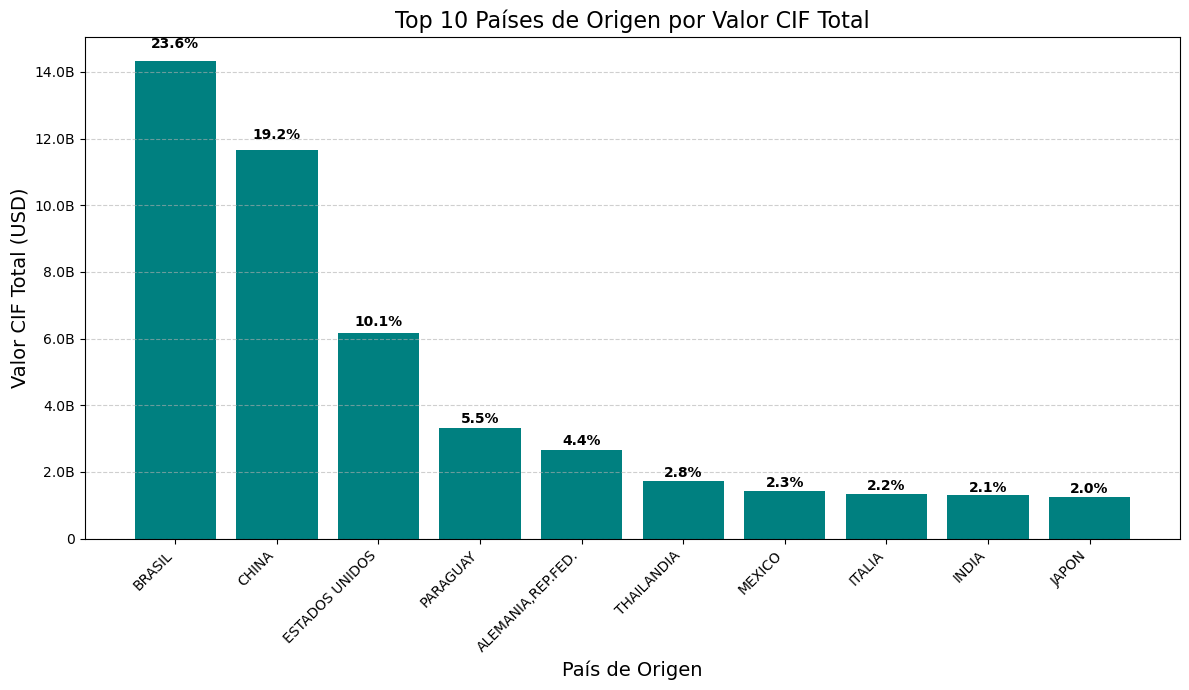


Tabla de Contribución del Top 10:
         nombre_pais      CIF(USD)  Porcentaje
0             BRASIL  1.433459e+10       23.59
1              CHINA  1.165819e+10       19.18
2     ESTADOS UNIDOS  6.162128e+09       10.14
3           PARAGUAY  3.314011e+09        5.45
4  ALEMANIA,REP.FED.  2.651900e+09        4.36
5         THAILANDIA  1.714948e+09        2.82
6             MEXICO  1.424146e+09        2.34
7             ITALIA  1.332902e+09        2.19
8              INDIA  1.294969e+09        2.13
9              JAPON  1.245426e+09        2.05


In [6]:
# --- A. Top 10 Países de Origen (Contribución al valor) ---

# 1. Agrupar y calcular el Valor CIF total por país
df_contribucion_pais = df_eda.groupby('nombre_pais')['CIF(USD)'].sum().reset_index()

# 2. Ordenar y seleccionar el Top 10
df_top10_pais = df_contribucion_pais.sort_values(by='CIF(USD)', ascending=False).head(10).reset_index(drop=True)

# 3. Calcular la contribución porcentual del Top 10 sobre el total
total_cif = df_eda['CIF(USD)'].sum()
df_top10_pais['Porcentaje'] = (df_top10_pais['CIF(USD)'] / total_cif) * 100

# 4. Visualización
plt.figure(figsize=(12, 7))
bars = plt.bar(
    df_top10_pais['nombre_pais'], 
    df_top10_pais['CIF(USD)'], 
    color='teal'
)

# Aplicar formato abreviado a los valores del eje Y (moneda)
def format_millions(x, pos):
    """Convierte un valor numérico a formato K, M o B."""
    if x >= 1e9:
        return f'{x*1e-9:.1f}B' # B de Billions (miles de millones)
    elif x >= 1e6:
        return f'{x*1e-6:.1f}M'
    elif x >= 1e3:
        return f'{x*1e-3:.0f}K'
    return f'{x:.0f}'

formatter = ticker.FuncFormatter(format_millions)
plt.gca().yaxis.set_major_formatter(formatter)
plt.xticks(rotation=45, ha='right')

# Iteramos sobre el DataFrame de Top 10 para obtener los datos y luego sobre las barras
for bar, porc in zip(bars, df_top10_pais['Porcentaje']):
    yval = bar.get_height()
    
    plt.text(
        bar.get_x() + bar.get_width()/2, 
        yval + yval*0.02, # Coloca el texto un 2% por encima de la barra
        f'{porc:.1f}%', 
        ha='center', 
        va='bottom',
        fontsize=10,
        weight='bold'
    )


plt.title('Top 10 Países de Origen por Valor CIF Total', fontsize=16)
plt.xlabel('País de Origen', fontsize=14)
plt.ylabel('Valor CIF Total (USD)', fontsize=14)
plt.grid(axis='y', linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()

print("\nTabla de Contribución del Top 10:")
print(df_top10_pais[['nombre_pais', 'CIF(USD)', 'Porcentaje']].round(2))

## Insight: Este análisis nos muestra que una pequeña cantidad de países (Brasil, China, EE. UU.) dominan el valor de las importaciones. Estos países deben ser tratados como features categóricas de alta importancia, posiblemente usando One-Hot Encoding en el modelado.

### B. Top 10 Capítulos arancelarios (NCM de 2 Dígitos)

Los capítulos arancelarios (NCM_2_digitos) representan categorías amplias (ej. 84 para Máquinas, 87 para Vehículos).

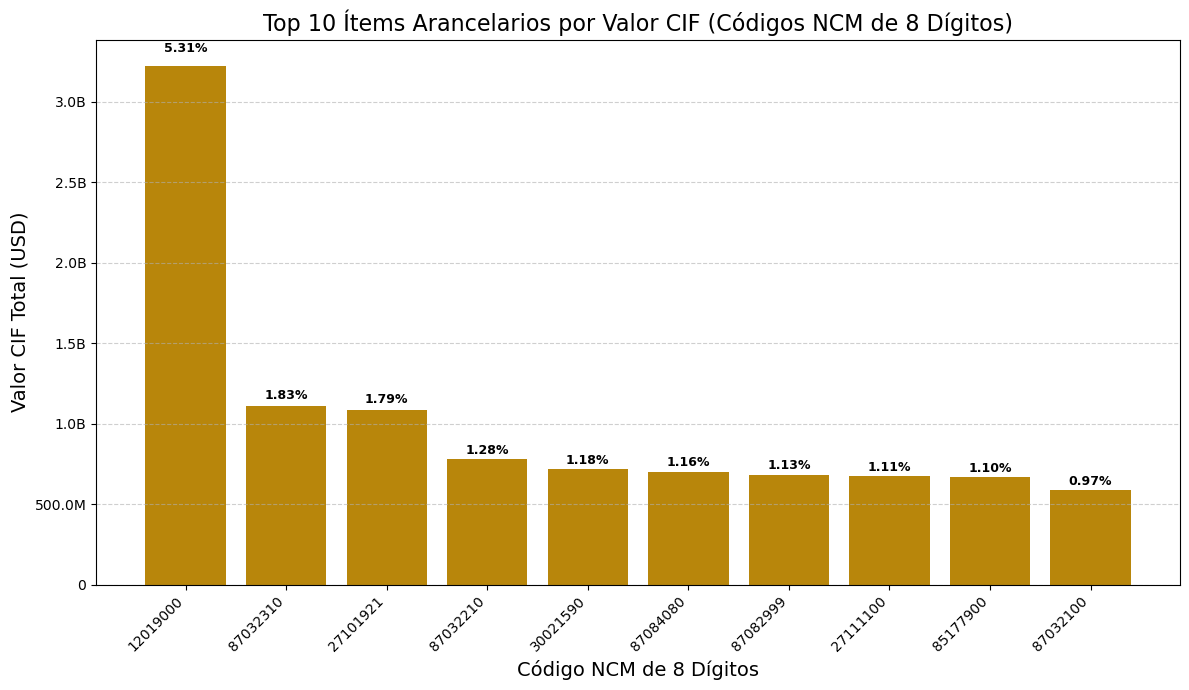


Tabla de Contribución del Top 10 Ítems NCM (8 Dígitos - CÓDIGOS):
  NCM_8_digitos      CIF(USD)  Porcentaje
0      12019000  3.224941e+09       5.306
1      87032310  1.112059e+09       1.830
2      27101921  1.087772e+09       1.790
3      87032210  7.789684e+08       1.282
4      30021590  7.157654e+08       1.178
5      87084080  7.024994e+08       1.156
6      87082999  6.843056e+08       1.126
7      27111100  6.755012e+08       1.111
8      85177900  6.660246e+08       1.096
9      87032100  5.885843e+08       0.968


In [7]:
import matplotlib.ticker as ticker 
import matplotlib.pyplot as plt

# Asegúr de que la columna NCM_8_digitos sea string y esté limpia (rellenada con ceros).
df_eda['NCM_8_digitos'] = df_eda['NCM_8_digitos'].astype(str).str.zfill(8)

# --- 1. Agrupar y calcular la contribución por CÓDIGO de 8 dígitos ---
df_contribucion_codigos_8d = df_eda.groupby('NCM_8_digitos')['CIF(USD)'].sum().reset_index()

# 2. Ordenar y seleccionar el Top 10
df_top10_codigos_8d = df_contribucion_codigos_8d.sort_values(by='CIF(USD)', ascending=False).head(10).reset_index(drop=True)

# 3. Calcular la contribución porcentual del Top 10
total_cif = df_eda['CIF(USD)'].sum()
df_top10_codigos_8d['Porcentaje'] = (df_top10_codigos_8d['CIF(USD)'] / total_cif) * 100

# 4. Visualización

plt.figure(figsize=(12, 7))
bars = plt.bar(
    df_top10_codigos_8d['NCM_8_digitos'], # Eje X: El código de 8 dígitos
    df_top10_codigos_8d['CIF(USD)'], 
    color='darkgoldenrod' # Nuevo color para distinguirlo
)

# Definición de la función para formato abreviado de moneda
def format_millions(x, pos):
    """Convierte un valor numérico a formato K, M o B."""
    if x >= 1e9:
        return f'{x*1e-9:.1f}B'
    elif x >= 1e6:
        return f'{x*1e-6:.1f}M'
    elif x >= 1e3:
        return f'{x*1e-3:.0f}K'
    return f'{x:.0f}'

formatter = ticker.FuncFormatter(format_millions)
plt.gca().yaxis.set_major_formatter(formatter)
plt.xticks(rotation=45, ha='right') # Necesario para que los códigos no se superpongan

# Añadir el porcentaje sobre cada barra
for bar, porc in zip(bars, df_top10_codigos_8d['Porcentaje']):
    yval = bar.get_height()
    plt.text(
        bar.get_x() + bar.get_width()/2, 
        yval + yval*0.02, 
        f'{porc:.2f}%', # Usamos dos decimales, ya que el porcentaje será pequeño
        ha='center', 
        va='bottom',
        fontsize=9,
        weight='bold'
    )

plt.title('Top 10 Ítems Arancelarios por Valor CIF (Códigos NCM de 8 Dígitos)', fontsize=16)
plt.xlabel('Código NCM de 8 Dígitos', fontsize=14)
plt.ylabel('Valor CIF Total (USD)', fontsize=14)
plt.grid(axis='y', linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()

print("\nTabla de Contribución del Top 10 Ítems NCM (8 Dígitos - CÓDIGOS):")
print(df_top10_codigos_8d[['NCM_8_digitos', 'CIF(USD)', 'Porcentaje']].round(3))

## Insight: Esto permite segmentar el problema. Los NCMs que concentran la mayor parte del valor (ej. Bienes Intermedios o Bienes de Capital) son donde el modelo de regresión tendrá el mayor impacto predictivo.

# ANALSISI DE DENSIDAD DE VALOR

## 1-Preparacion y calculo de USD /kg

In [8]:
import pandas as pd
import matplotlib.ticker as ticker 
import matplotlib.pyplot as plt

# --- 1. Preparación y cálculo de USD/kg ---

# Asegurar que las columnas existan y sean numéricas (el peso debe ser > 0)
df_eda['CIF(USD)'] = pd.to_numeric(df_eda['CIF(USD)'], errors='coerce')
df_eda['Peso_Neto_kg'] = pd.to_numeric(df_eda['Peso_Neto_kg'], errors='coerce') 

# Eliminar o manejar registros donde el peso es cero o nulo para el cálculo unitario
df_calculo = df_eda.dropna(subset=['CIF(USD)', 'Peso_Neto_kg']).copy()
df_calculo = df_calculo[df_calculo['Peso_Neto_kg'] > 0]

# --- Agrupación por Partida (4 Dígitos) ---
# Sumar el Valor (CIF) y el Peso (KG) por Partida Arancelaria
df_valor_unitario = df_calculo.groupby('NCM_4_digitos').agg(
    Total_CIF=('CIF(USD)', 'sum'),
    Total_KG=('Peso_Neto_kg', 'sum') 
).reset_index()

# Calcular el Valor Unitario (USD/kg)
df_valor_unitario['USD_por_KG'] = df_valor_unitario['Total_CIF'] / df_valor_unitario['Total_KG']

# 2. Ordenar y seleccionar el Top 10 de mayor valor unitario
df_top10_precio = df_valor_unitario.sort_values(by='USD_por_KG', ascending=False).head(10).reset_index(drop=True)

print("✅ Cálculo de Valor Unitario (USD/kg) por Partida Arancelaria completado.")

✅ Cálculo de Valor Unitario (USD/kg) por Partida Arancelaria completado.


## 2-Visualización del top 10 de mayor densidad de valor

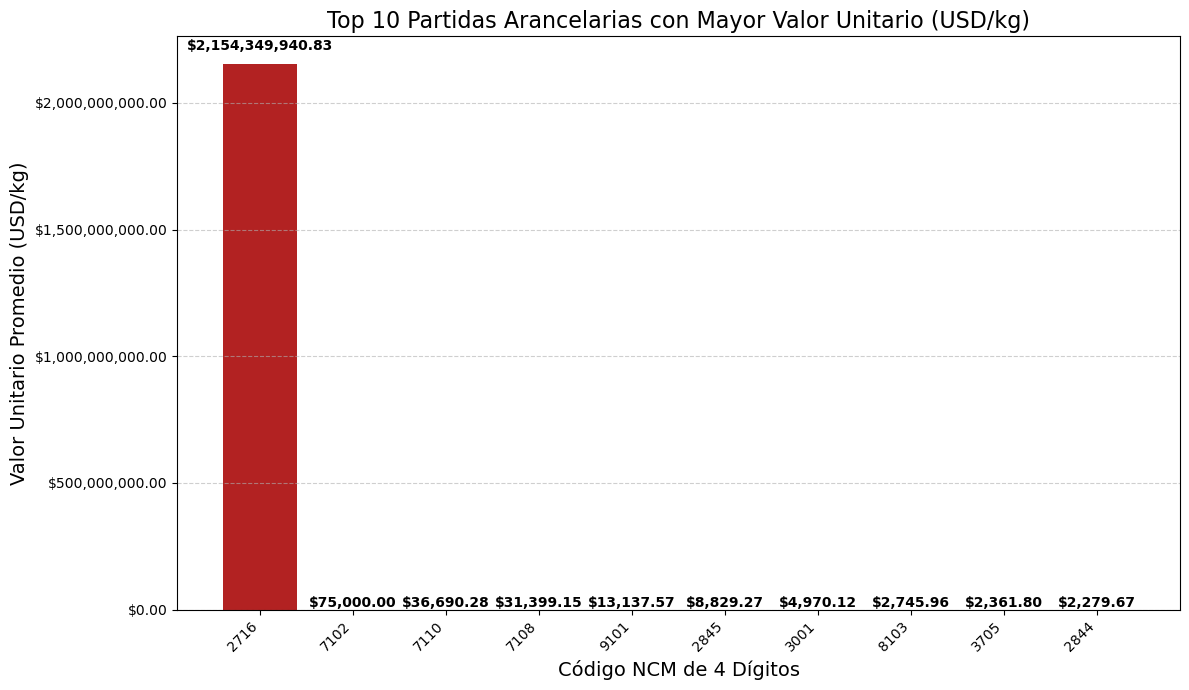


--- Tabla de Top 10 Partidas por Valor Unitario (USD/kg) ---
  NCM_4_digitos    USD_por_KG    Total_CIF  Total_KG
0          2716  2.154350e+09  25852199.29      0.01
1          7102  7.500000e+04     37500.00      0.50
2          7110  3.669028e+04  63551604.92   1732.11
3          7108  3.139915e+04     24805.33      0.79
4          9101  1.313757e+04   3355270.28    255.40
5          2845  8.829270e+03    112308.29     12.72
6          3001  4.970120e+03  17971813.35   3615.97
7          8103  2.745960e+03     54864.27     19.98
8          3705  2.361800e+03      1653.26      0.70
9          2844  2.279670e+03   5142452.47   2255.79


In [28]:
# --- 2. Visualización del Top 10 de mMayor densidad de valor ---

plt.figure(figsize=(12, 7))
bars = plt.bar(
    df_top10_precio['NCM_4_digitos'], 
    df_top10_precio['USD_por_KG'], 
    color='firebrick'
)

# Formatear el eje Y con dos decimales para el precio
formatter = ticker.StrMethodFormatter('${x:,.2f}')
plt.gca().yaxis.set_major_formatter(formatter)

plt.xticks(rotation=45, ha='right')

# Añadir el valor USD/KG sobre cada barra
for bar in bars:
    yval = bar.get_height()
    plt.text(
        bar.get_x() + bar.get_width()/2, 
        yval + yval*0.02, 
        f'${yval:,.2f}', 
        ha='center', 
        va='bottom',
        fontsize=10,
        weight='bold'
    )

plt.title('Top 10 Partidas Arancelarias con Mayor Valor Unitario (USD/kg)', fontsize=16)
plt.xlabel('Código NCM de 4 Dígitos', fontsize=14)
plt.ylabel('Valor Unitario Promedio (USD/kg)', fontsize=14)
plt.grid(axis='y', linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()

print("\n--- Tabla de Top 10 Partidas por Valor Unitario (USD/kg) ---")
print(df_top10_precio[['NCM_4_digitos', 'USD_por_KG', 'Total_CIF', 'Total_KG']].round(2))

# 4. Conclusión del EDA

## El EDA confirma que el problema de regresión es complejo debido a:

### * Distribución sesgada: El target (CIF(USD)) requiere modelos que manejen bien los outliers y la heterocedasticidad (ej. SVR o Transformaciones Logarítmicas).

### * Influencia categórica Fuerte: Una pequeña cantidad de Países y NCMs concentran la mayor parte del valor, justificando la inclusión de estas variables categóricas.

### * Componente temporal: Existe una tendencia y estacionalidad claras que deben ser capturadas por el modelo (ej. usando la variable Mes).

# Estos insights serán la base para justificar el modelo de regresión en la próxima entrega.

# 5. Guardado de archivo

In [9]:
import os
import pandas as pd

# 1. Definir la ruta de destino (asumiendo que quieres guardarlo cerca de tus otros archivos)
# Usaremos la misma ruta que usaste antes para tu carpeta de proyectos, pero ajustando la subcarpeta.
ruta_carpeta_destino = r'G:\tecnicatura en cd e ia\2025\SEGUNDO AÑO\2do año 1er cuatrimestre\aprendizaje automatico\PROYECTOS AA\actividades de ML\PARCIAL_AA_2025\data\04-dataset definitivo'
nombre_archivo_final = 'df_eda_final_para_ML.parquet'

ruta_completa_guardado = os.path.join(ruta_carpeta_destino, nombre_archivo_final)

# 2. Guardar el DataFrame
df_eda.to_parquet(ruta_completa_guardado, index=False)

print(f"✅ DataFrame final del EDA guardado exitosamente en:\n{ruta_completa_guardado}")

✅ DataFrame final del EDA guardado exitosamente en:
G:\tecnicatura en cd e ia\2025\SEGUNDO AÑO\2do año 1er cuatrimestre\aprendizaje automatico\PROYECTOS AA\actividades de ML\PARCIAL_AA_2025\data\04-dataset definitivo\df_eda_final_para_ML.parquet
